# Insurance Data Preprocessing

Basic preprocessing and visualization for the insurance dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the data

In [2]:
df = pd.read_csv("/mnt/data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Check the dataset

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 1338
Columns: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Check missing values

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

There are no missing values in the dataset.

## Check duplicated rows

In [6]:
df.duplicated().sum()

np.int64(1)

There is one duplicated row, so it will be removed.

In [7]:
df = df.drop_duplicates().reset_index(drop=True)

df.duplicated().sum()

np.int64(0)

## Visualization

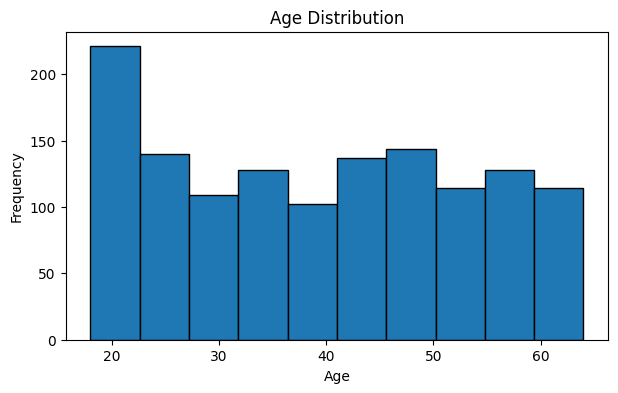

In [8]:
plt.figure(figsize=(7, 4))
plt.hist(df["age"], bins=10, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

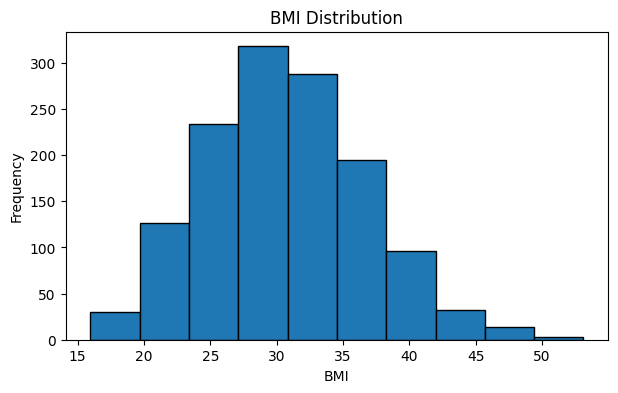

In [9]:
plt.figure(figsize=(7, 4))
plt.hist(df["bmi"], bins=10, edgecolor="black")
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

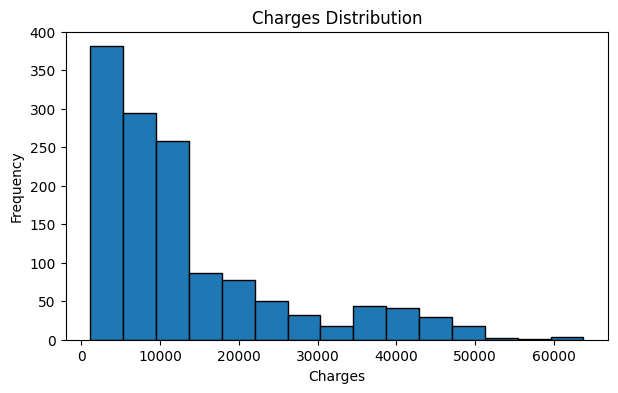

In [10]:
plt.figure(figsize=(7, 4))
plt.hist(df["charges"], bins=15, edgecolor="black")
plt.title("Charges Distribution")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

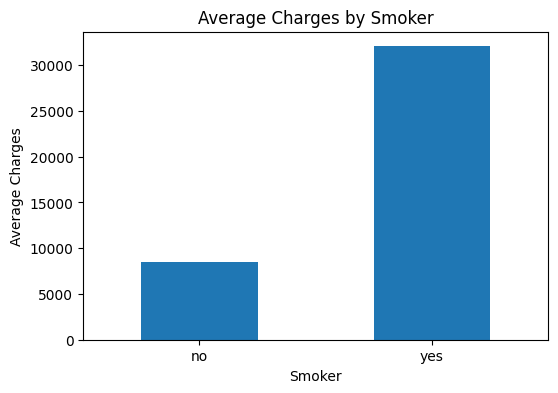

In [11]:
smoker_charges = df.groupby("smoker")["charges"].mean()

plt.figure(figsize=(6, 4))
smoker_charges.plot(kind="bar")
plt.title("Average Charges by Smoker")
plt.xlabel("Smoker")
plt.ylabel("Average Charges")
plt.xticks(rotation=0)
plt.show()

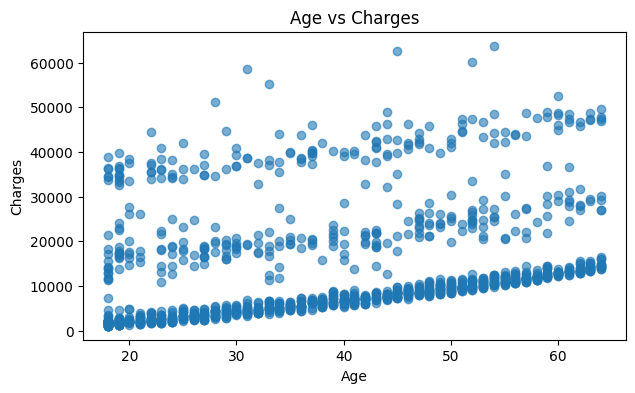

In [12]:
plt.figure(figsize=(7, 4))
plt.scatter(df["age"], df["charges"], alpha=0.6)
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

## Check categorical columns

In [13]:
print("sex:", df["sex"].unique())
print("smoker:", df["smoker"].unique())
print("region:", df["region"].unique())

sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


`sex` and `smoker` have two categories, so they can be converted to 0 and 1.  
`region` has four categories, so dummy columns will be created.

## Encode categorical data

In [14]:
df["sex"] = df["sex"].map({"female": 0, "male": 1})
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

df = pd.get_dummies(df, columns=["region"], dtype=int)

df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


## Final check

In [15]:
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Shape: (1337, 10)

age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northeast      int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

Missing values: 0
Duplicates: 0


## Separate features and target

In [16]:
X = df.drop("charges", axis=1)
y = df["charges"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1337, 9)
y shape: (1337,)


In [17]:
X.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,0,1
1,18,1,33.770,1,0,0,0,1,0
2,28,1,33.000,3,0,0,0,1,0
3,33,1,22.705,0,0,0,1,0,0
4,32,1,28.880,0,0,0,1,0,0
